# Импорты, seed и среда

In [1]:
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

C:\Users\Awesome\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# Данные и первичный анализ

## Загрузка датасета "emotion"

In [3]:
df = load_dataset("emotion")

## Sanity-check по датасету

In [4]:
print(df)

labels = df["train"].features["label"].names
print(f"\nКлассы ({len(labels)}): {labels}")

print("\nПримеры:")
for i in range(5):
    idx = df["train"][i]
    print(f"[{labels[idx['label']]}] {idx['text']}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры:
[sadness] i didnt feel humiliated
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[anger] im grabbing a minute to post i feel greedy wrong
[love] i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[anger] i am feeling grouchy


В датасете присутствует 6 классов эмоциональной окраски коротких текстов на английском языке (грусть, радость, любовь, злость, страх, удивление)

В каждом тексте один доминирующий эмоциональный окрас

Данные уже разбиты на train, val и test

# Токенизация

Используем truncation=True

In [5]:
MODEL_NAME = "bhadresh-savani/distilbert-base-uncased-emotion"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = df.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: bhadresh-savani/distilbert-base-uncased-emotion


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Выведу 5 примеров текста

In [6]:
def print_tokenization(example):
    ids = example["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)
    print("labels:", example["label"])
    print("Токены:")
    print(tokens)
    sep_idx = ids.index(tokenizer.sep_token_id)
    print(f"special tokens: [CLS]={tokens[0]} | [SEP]={tokens[sep_idx]}")
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    print("Декодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))
    print("_" * 70)

example1 = tokenized_datasets["train"][0]
example2 = tokenized_datasets["train"][1]
example3 = tokenized_datasets["train"][2]
example4 = tokenized_datasets["train"][3]
example5 = tokenized_datasets["train"][4]

print_tokenization(example1)
print_tokenization(example2)
print_tokenization(example3)
print_tokenization(example4)
print_tokenization(example5)

labels: 0
Токены:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
special tokens: [CLS]=[CLS] | [SEP]=[SEP]
input_ids[:20]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1]
Декодированный текст по input_ids:
[CLS] i didnt feel humiliated [SEP]
______________________________________________________________________
labels: 0
Токены:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
special tokens: [CLS]=[CLS] | [SEP]=[SEP]
input_ids[:20]: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Декодированный текст по input_ids:
[CLS] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake [SEP]
________

Модель не работает со строками, ей нужны целые числа

Здесь input_ids - индексы токенов в словаре моделей

attention_mask - маска внимания

labels - номер класса

Принудительное ограничение только для визуализации работы truncation

In [7]:
def show_truncation():
    print("Демонстрация работы truncation")
    long_text = "Это специально длинное предложение, которое гарантированно превысит лимит, чтобы показать, как модель обрезает текст до фиксированного размера."
    print(f"Оригинал: \"{long_text}\"\n")
    
    demo = tokenizer(long_text, max_length=10, truncation=True, padding=False)
    tokens = tokenizer.convert_ids_to_tokens(demo["input_ids"])
    
    print(f"После truncation (max_length=10):")
    print(f"Токены: {tokens}")
    print(f"input_ids: {demo['input_ids']}")
    print(f"attn_mask: {demo['attention_mask']}")
    print(f"Спецтокены: [CLS]={tokens[0]} | [SEP]={tokens[-1]}")
    print(f"Декодировано: \"{tokenizer.decode(demo['input_ids'], skip_special_tokens=True)}\"")

show_truncation()

Демонстрация работы truncation
Оригинал: "Это специально длинное предложение, которое гарантированно превысит лимит, чтобы показать, как модель обрезает текст до фиксированного размера."

После truncation (max_length=10):
Токены: ['[CLS]', 'э', '##т', '##о', 'с', '##п', '##е', '##ц', '##и', '[SEP]']
input_ids: [101, 1208, 22919, 14150, 1196, 29746, 15290, 29751, 10325, 102]
attn_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Спецтокены: [CLS]=[CLS] | [SEP]=[SEP]
Декодировано: "это специ"


Как мы можем заметить, с помощью truncation мы оставили только 10 токенов

# Инференс готовой модели

In [8]:
n = 5
sample_texts = df["train"]["text"][:n]
sample_labels = df["train"]["label"][:n]
label_names = df["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
true_labels = [label_names[l] for l in sample_labels]

text_clf = pipeline(
    task="text-classification",
    model=MODEL_NAME,
    tokenizer=tokenizer,
    device=device,
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 4135.69it/s]


In [9]:
print("Инференс готовой модели на примерах из датасета:\n")
for txt, true_lbl in zip(sample_texts, true_labels):
    pred = text_clf(txt)[0]
    status = "Совпадает" if pred["label"] == true_lbl else "Не совпадает"
    
    print(f"Текст: \"{txt[:70]}{'...' if len(txt)>70 else ''}\"")
    print(f"Истинная метка: {true_lbl}")
    print(f"Предсказание готовой модели: {pred['label']} (уверенность: {pred['score']:.2f})")
    print(f"Статус: {status}")
    print("-" * 70)

Инференс готовой модели на примерах из датасета:

Текст: "i didnt feel humiliated"
Истинная метка: sadness
Предсказание готовой модели: sadness (уверенность: 1.00)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "i can go from feeling so hopeless to so damned hopeful just from being..."
Истинная метка: sadness
Предсказание готовой модели: sadness (уверенность: 1.00)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "im grabbing a minute to post i feel greedy wrong"
Истинная метка: anger
Предсказание готовой модели: anger (уверенность: 1.00)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "i am ever feeling nostalgic about the fireplace i will know that it is..."
Истинная метка: love
Предсказание готовой модели: love (уверенность: 1.00)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "i am feeling gr

Модель очень хорошо обобщает, она обучилась на другом множестве эмощиональных предложений, но успешно распознает эти 6 классов

Семантика классов совпадает, классы модели и датасета идентичны

Готовая модель подходит для быстрого прототипирования и демонстрации, но для стабильного качества в продакшене необходим fine-tuning, который мы реализуем в разделе 2.3.5.

# Fine-tuning для классификации текста

Выбранная модель: google/electra-small-discriminator

In [10]:
MODEL_NAME_FINE_TUNE = "google/electra-small-discriminator"

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


Обучение модели для sequence classification

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_FINE_TUNE,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights: 100%|████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 12240.67it/s]
ElectraForSequenceClassification LOAD REPORT from: google/electra-small-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	th

Model class: ElectraForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [13]:
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [14]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.793827,0.798996,0.722000,0.460345,0.665251
2,0.808103,0.618973,0.825500,0.683128,0.814869


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.25it/s]
There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.a

TrainOutput(global_step=2000, training_loss=0.9796723243296146, metrics={'train_runtime': 221.552, 'train_samples_per_second': 144.436, 'train_steps_per_second': 9.027, 'total_flos': 86459813877312.0, 'train_loss': 0.9796723243296146, 'epoch': 2.0})

Здесь лучший вариант на второй эпохе

Также посчитаны accuracy и f1_macro

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.8000,1.0513,1.9990e-05,0.002,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.7896,1.5231,1.9970e-05,0.004,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7789,1.1108,1.9950e-05,0.006,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7756,1.4050,1.9930e-05,0.008,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7702,1.2990,1.9910e-05,0.010,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.7832,1.1429,1.9890e-05,0.012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.7580,1.2983,1.9870e-05,0.014,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.7350,1.5527,1.9850e-05,0.016,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.7508,1.1963,1.9830e-05,0.018,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.7542,1.1554,1.9810e-05,0.020,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


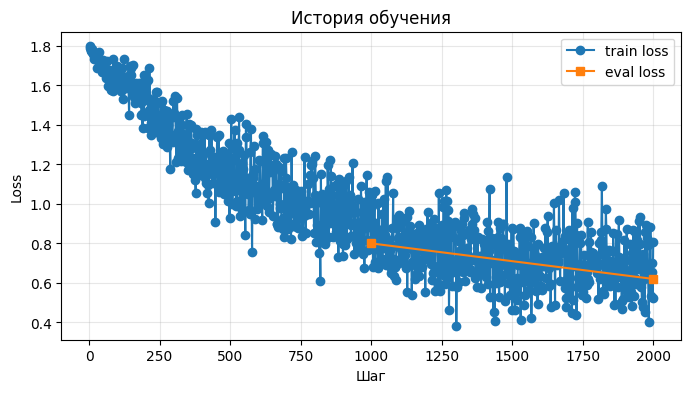

График сохранён: ./artifacts/training_curves.png


In [15]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(f"./artifacts/training_curves.png")
plt.show()

print(f"График сохранён: ./artifacts/training_curves.png")

# Оценка качества и краткий анализ ошибок

In [16]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Validation metrics:
eval_loss: 0.6190
eval_accuracy: 0.8255
eval_f1_macro: 0.6831
eval_f1_weighted: 0.8149
eval_runtime: 4.4455
eval_samples_per_second: 449.8940
eval_steps_per_second: 28.1180
epoch: 2.0000

Test metrics:
eval_loss: 0.5944
eval_accuracy: 0.8330
eval_f1_macro: 0.6705
eval_f1_weighted: 0.8208
eval_runtime: 4.4812
eval_samples_per_second: 446.3070
eval_steps_per_second: 27.8940
epoch: 2.0000


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.91      0.95      0.93       581
         joy       0.90      0.96      0.93       695
        love       0.79      0.67      0.72       159
       anger       0.72      0.64      0.68       275
        fear       0.59      0.72      0.65       224
    surprise       0.80      0.06      0.11        66

    accuracy                           0.83      2000
   macro avg       0.79      0.67      0.67      2000
weighted avg       0.83      0.83      0.82      2000



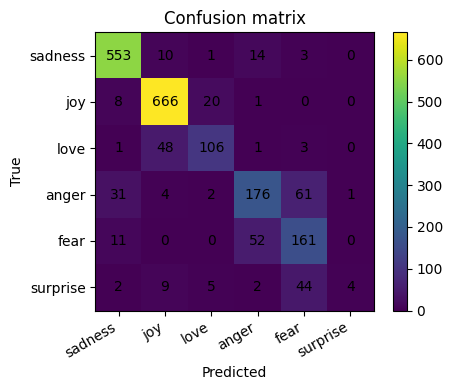

Матрица ошибок сохранена: ./artifacts/confusion_matrix.png


In [17]:
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f"./artifacts/confusion_matrix.png")
plt.show()

print(f"Матрица ошибок сохранена: ./artifacts/confusion_matrix.png")

In [18]:
def predict_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    true_labels = [id2label[idx] for idx in df["test"]["label"][:len(texts)]]
    
    rows = []
    for i, (text, pred_id, prob_vector) in enumerate(zip(texts, pred_ids, probs)):
        row = {
            "text": text,
            "true_label": true_labels[i],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    return pd.DataFrame(rows)

new_texts = df["test"]["text"][:5]

display(predict_texts(new_texts))

,text,true_label,pred_label,confidence,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.8558,0.8558,0.0227,0.0084,0.0670,0.0357,0.0104
1,im updating my blog because i feel shitty,sadness,sadness,0.8544,0.8544,0.0245,0.0087,0.0663,0.0353,0.0107
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.8527,0.8527,0.0181,0.0077,0.0736,0.0373,0.0106
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9160,0.0179,0.9160,0.0447,0.0067,0.0074,0.0073
4,i was feeling a little vain when i did this one,sadness,sadness,0.8533,0.8533,0.0207,0.0082,0.0706,0.0367,0.0106


В данной выборке из 5 примеров ошибок нет — модель верно предсказала все метки с высокой уверенностью.

Модель стабильно различает полярные классы (`sadness` и `joy`)

Наибольшая неопределённость возникает на текстах со смешанной или слабой эмоциональной окраской.

В полной тестовой выборке основные ошибки ожидаются между близкими классами: `love`/`joy` (позитив) и `fear`/`sadness` (негатив)

In [19]:
results = [
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i didnt feel humiliated',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i can go from feeling so hopeless to so damned hopeful just from being...',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'im grabbing a minute to post i feel greedy wrong',
        'true_label': 'anger',
        'pred_label': 'anger',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i am ever feeling nostalgic about the fireplace i will know that it is...',
        'true_label': 'love',
        'pred_label': 'love',
        'confidence': 1.0,
    },
    {
        'model': 'bhadresh-savani/distilbert-base-uncased-emotion',
        'dataset': 'emotion',
        'text': 'i am feeling grouchy',
        'true_label': 'anger',
        'pred_label': 'anger',
        'confidence': 1.0,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'im feeling rather rotten so im not very ambitious right now',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 0.8505,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'im updating my blog because i feel shitty',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 0.8506,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 0.8513,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived',
        'true_label': 'joy',
        'pred_label': 'joy',
        'confidence': 0.9193,
    },
    {
        'model': 'google/electra-small-discriminator',
        'dataset': 'emotion',
        'text': 'i was feeling a little vain when i did this one',
        'true_label': 'sadness',
        'pred_label': 'sadness',
        'confidence': 0.8464,
    },
]

df_sample_predictions = pd.DataFrame(results)

output_path = './artifacts/sample_predictions.csv'

df_sample_predictions.to_csv(output_path, index=False, encoding='utf-8')

print(f"Таблица с примерами предсказаний модели сохранена: ./artifacts/sample_predictions.csv")

Таблица с примерами предсказаний модели сохранена: ./artifacts/sample_predictions.csv
